# Thermal X-ray Emission near AGN particles

In this notebook, we will use OpenCosmo in coordination with [yt](https://yt-project.org/) and [pyxsim](https://hea-www.cfa.harvard.edu/~jzuhone/pyxsim/) to compute X-ray luminosity in different bands for gas around AGN particles, considering thermal emission. The overall strategy for this calculation is:

1. Use the OpenCosmo Toolkit to associate particle data with halos and identify the positions of AGN particles
2. Use yt/pyxsim to draw a sphere around each AGN particle and compute the total x-ray luminosity for gas particles in three separate bands
3. Repeat step 2 for a number of halos, and compute x-ray hardness ratio for each sphere

We will also investigate how x-ray luminosities/hardness ratios are related to whether a given AGN particle is emitting thermal vs. mechanical (kinetic) feedback.

<div class="meta-block">
  <div class="meta-row">
    <span class="meta-label">Data</span>
    <span class="chip chip-data">Halo Properties</span>
    <span class="chip chip-data">Halo Particles</span>
  </div>

  <div class="meta-row">
    <span class="meta-label">Tasks</span>
    <span class="chip chip-task">Evaluate</span>
    <span class="chip chip-task">Spatial Operations</span>
    <span class="chip chip-task">Visualization</span>

  </div>
</div>

[![Open in NERSC JupyterHub](https://img.shields.io/badge/launch-NERSC%20JupyterHub-blue?logo=jupyter&logoColor=white)](https://jupyter.nersc.gov/hub/user-redirect/git-pull?repo=https://github.com/ArgonneCPAC/opencosmo-examples&urlpath=lab/tree/opencosmo-examples/tutorials/xray_agn.ipynb&branch=main)


:::{tip} Additional Dependencies
:class: dropdown

This tutorial requires [yt](https://yt-project.org/) and [pyxsim](https://hea-www.cfa.harvard.edu/~jzuhone/pyxsim/) in addition to the OpenCosmo toolkit. Install them with:
```
pip install yt pyxsim
```
:::

In [2]:
import numpy as np
import opencosmo as oc
from opencosmo.analysis import create_yt_dataset
import yt
from yt.units import Mpc, km, s, yr, Msun, keV
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path

data_root = Path("/global/cfs/cdirs/hacc/www/OpenCosmo/xray-emission-near-agn")

ds = oc.open(data_root / "halos_and_particles.hdf5")


soxs : [WARNING  ] 2026-05-05 13:05:59,806 Setting 'soxs_data_dir' to /Users/willhicks/Library/Caches/soxs for this session. Please update your configuration if you want it somewhere else.


We will consider three energy ranges, corresponding to soft emission (0.5-1.2 keV), hard emission (2.0-7.0 keV), and bolometric (0.5-7.0 keV).

In [3]:
# define energy ranges
e0 = [0.5,1.2] # soft x-ray, in keV
e1 = [2.0,7.0] # hard x-ray, in keV
ebol = [0.5, 7.0] # total range we care about, in keV
R = 50 # sampling sphere radius in units of kpc

# pyxsim will store x-ray luminosity in the fields with these names
L0 = f"xray_luminosity_{e0[0]:.1f}_{e0[1]:.1f}_keV"
L1 = f"xray_luminosity_{e1[0]:.1f}_{e1[1]:.1f}_keV"
Lbol = f"xray_luminosity_{ebol[0]:.1f}_{ebol[1]:.1f}_keV"

Set up derived fields for yt datasets. The decorator `@yt.derived_field` tells yt to compute and store the field defined by the subsequent function any time a yt dataset is created.

The following quantities will be computed for each AGN particle:

1. Eddington accretion rate
2. The ratio between the Bondi-Hoyle accretion rate and the Eddington accretion rate: $\chi\equiv\frac{\dot{M}_\mathrm{Bondi-Hoyle}}{\dot{M}_\mathrm{Eddington}}$
3. Threshold value of $\chi$ for determining if the AGN particle is set to emit thermal or mechanical (kinetic) feedback.

In [4]:
# Eddington accretion rate
@yt.derived_field(
    name=("agn", "eddr"),
    sampling_type="particle",
    units="Msun/yr",
)
def _eddington(field, data):
    agn_rad_eff = 0.2 
    edd_const = 2.21857e-9 * 1/yr # 1/yr
    hubble = 0.6766
    edd_rate = edd_const / agn_rad_eff * data["agn","mbh"].to("Msun") * hubble
    return edd_rate

# Bondi-Hoyle accretion rate, divided by the Eddington accretion rate. 
# This quantity, Chi, is used internally by HACC to determine if an AGN is emitting thermal or kinetic feedback.
@yt.derived_field(
    name=("agn", "chi"),
    sampling_type="particle",
    units="dimensionless",
)
def _chi(field, data):
    return data["agn","bhr"]/data["agn","eddr"]

# The Chi threshold for determining if an AGN is in thermal mode or kinetic mode.
@yt.derived_field(
    name=("agn", "chi_threshold"),
    sampling_type="particle",
    units="dimensionless",
)
def _chi_threshold(field, data):
    chi_0 = 0.002
    beta = 2.0
    chi_max = 0.1

    chi_t = chi_0 * data["agn", "mbh"].to("Msun")/(1e8*Msun)
    chi_t[chi_t > chi_max] = chi_max

    return chi_t

Now, we will loop through all halos and convert the particle data to a yt dataset. We will use yt to select a 50 kpc sphere around each AGN particle and compute the total thermal x-ray luminosity within the sphere.

In [5]:
L_soft, L_hard, L_bol = [], [], []
M = []
chi, chi_ratio = [], []

# loop through halos
for j, halo in enumerate(ds.halos()):
    
    # Convert particle data for halo into a yt dataset. 
    # With `compute_xray_fields=True`, the pyxsim tool is used to compute
    # x-ray luminosities from gas assuming thermal emission from gas in collisional ionization equilibrium.
    # See this link for a description of pyxsim's thermal models:
    #               https://hea-www.cfa.harvard.edu/~jzuhone/pyxsim/source_models/thermal_sources.html
    # Here, we will compute luminosities for the bolometric energy range.
    ds_yt, source_model = create_yt_dataset(halo,
        compute_xray_fields = True, return_source_model = True, 
        source_model_kwargs={"emin": ebol[0], "emax": ebol[1]}
    )
    
    # compute separate x-ray luminosity fields for soft and hard emission.
    # The `source_model` that is returned by `create_yt_dataset` is an instance of pyxsim's `CIESourceModel`
    source_model.make_source_fields(ds_yt, e0[0], e0[1]) 
    source_model.make_source_fields(ds_yt, e1[0], e1[1])
    
    # Get positions, masses, etc. from all agn particles in the halo
    ad = ds_yt.all_data()
    
    x_agn, y_agn, z_agn = ad["agn","particle_position_x"], ad["agn","particle_position_y"], ad["agn","particle_position_z"]
    mbh_agn = ad["agn","mbh"]

    chi_agn = ad["agn","chi"]
    chi_agn_thresh = ad["agn","chi_threshold"]
    
    chi_agn_ratio = chi_agn/chi_agn_thresh

    # Loop through AGN particles
    for i in range(len(x_agn)):
        x, y, z = x_agn[i], y_agn[i], z_agn[i]
        mbh = mbh_agn[i]
    
        # construct a small sphere around each AGN
        sp = ds_yt.sphere([x, y, z], (R, "kpc"))
    
        # get total x-ray luminosity in the sphere for each band
        L0_gas = sp.quantities.total_quantity(L0).to("erg/s") 
        L1_gas = sp.quantities.total_quantity(L1).to("erg/s") 
        Lbol_gas = sp.quantities.total_quantity(Lbol).to("erg/s") 
    
        # update lists
        L_soft.append(L0_gas)
        L_hard.append(L1_gas)
        L_bol.append(Lbol_gas)
        M.append(mbh)
    
        chi.append(chi_agn[i].d)
        chi_ratio.append(chi_agn_ratio[i].d)

# compute hardness ratios
L_ratio = np.array(L_hard)/np.array(L_soft)

yt : [INFO     ] 2026-05-05 13:06:03,622 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-05 13:06:03,623 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-05-05 13:06:03,625 Parameters: domain_left_edge          = [ 46.92944336 121.64714813  33.85173416]
yt : [INFO     ] 2026-05-05 13:06:03,626 Parameters: domain_right_edge         = [ 56.20596695 130.93569946  43.1293335 ]
yt : [INFO     ] 2026-05-05 13:06:03,627 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-05-05 13:06:03,629 Allocating for 8.643e+05 particles
pyxsim : [INFO     ] 2026-05-05 13:06:06,570 kT_min = 0.025 keV
pyxsim : [INFO     ] 2026-05-05 13:06:06,571 kT_max = 64 keV
pyxsim : [INFO     ] 2026-05-05 13:06:06,572 Using emission measure field '('gas', 'emission_measure')'.
pyxsim : [INFO     ] 2026-05-05 13:06:06,573 Using temperature field '('gas', 'temperature')'.


Preparing spectrum table :   0%|          | 0/138 [00:00<?, ?it/s]

pyxsim : [INFO     ] 2026-05-05 13:06:15,343 Using emission measure field '('gas', 'emission_measure')'.
pyxsim : [INFO     ] 2026-05-05 13:06:15,344 Using temperature field '('gas', 'temperature')'.


Preparing spectrum table :   0%|          | 0/138 [00:00<?, ?it/s]

pyxsim : [INFO     ] 2026-05-05 13:06:19,957 Using emission measure field '('gas', 'emission_measure')'.
pyxsim : [INFO     ] 2026-05-05 13:06:19,958 Using temperature field '('gas', 'temperature')'.


...

Preparing spectrum table :   0%|          | 0/138 [00:00<?, ?it/s]

pyxsim : [INFO     ] 2026-05-05 13:14:59,248 Using emission measure field '('gas', 'emission_measure')'.
pyxsim : [INFO     ] 2026-05-05 13:14:59,249 Using temperature field '('gas', 'temperature')'.


Preparing spectrum table :   0%|          | 0/138 [00:00<?, ?it/s]

pyxsim : [INFO     ] 2026-05-05 13:15:03,719 Using emission measure field '('gas', 'emission_measure')'.
pyxsim : [INFO     ] 2026-05-05 13:15:03,719 Using temperature field '('gas', 'temperature')'.


Preparing spectrum table :   0%|          | 0/138 [00:00<?, ?it/s]

Now that we have our array of luminosities, we can compute distributions of $L_\mathrm{soft}$, $L_\mathrm{hard}$, and $\frac{L_\mathrm{hard}}{L_\mathrm{soft}}$ as functions of $M$, $\chi$, and $\chi_\mathrm{thresh}$.

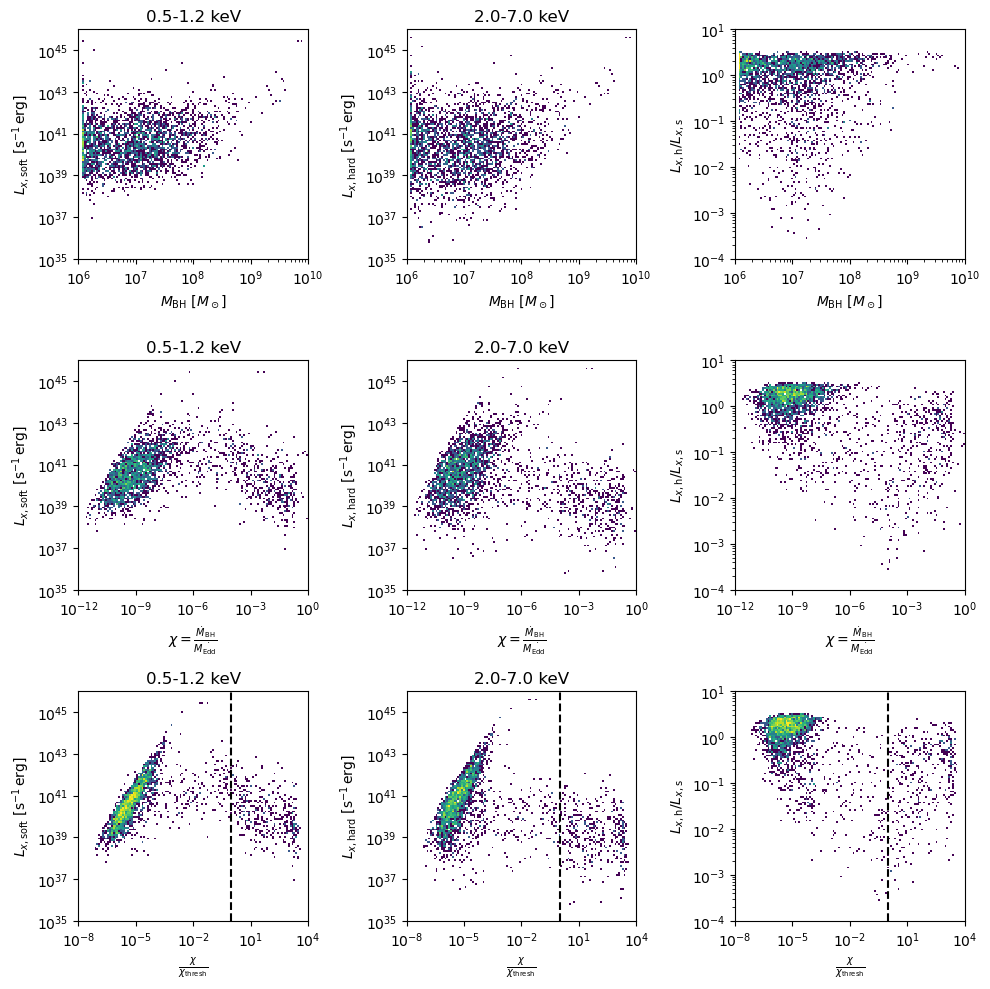

In [6]:
bins_Lx = np.geomspace(1e35, 1e46, 128)
bins_Lx_ratio = np.geomspace(1e-4, 1e1, 128)

bins_M = np.geomspace(1e6, 1e10, 128)
bins_chi = np.geomspace(1e-12, 1e0, 128)

bins_chi_ratio = np.geomspace(1e-8, 1e4, 128)

norm=LogNorm(vmin=1)

# compute 2D histograms
h1, x1, y1 = np.histogram2d(M, L_soft, bins = [bins_M, bins_Lx])
h2, x2, y2 = np.histogram2d(M, L_hard, bins = [bins_M, bins_Lx])
h3, x3, y3 = np.histogram2d(M, L_ratio, bins = [bins_M, bins_Lx_ratio])
h4, x4, y4 = np.histogram2d(chi, L_soft, bins = [bins_chi, bins_Lx])
h5, x5, y5 = np.histogram2d(chi, L_hard, bins = [bins_chi, bins_Lx])
h6, x6, y6 = np.histogram2d(chi, L_ratio, bins = [bins_chi, bins_Lx_ratio])
h7, x7, y7 = np.histogram2d(chi_ratio, L_soft, bins = [bins_chi_ratio, bins_Lx])
h8, x8, y8 = np.histogram2d(chi_ratio, L_hard, bins = [bins_chi_ratio, bins_Lx])
h9, x9, y9 = np.histogram2d(chi_ratio, L_ratio, bins = [bins_chi_ratio, bins_Lx_ratio])

# plot data
fig, [[ax1, ax2, ax3], [ax4, ax5, ax6], [ax7, ax8, ax9]] = plt.subplots(3,3)
fig.set_size_inches((10,10))

X, Y = np.meshgrid(x1, y1)
ax1.pcolormesh(X, Y, h1.T, norm=norm) 

X, Y = np.meshgrid(x2, y2)
ax2.pcolormesh(X, Y, h2.T, norm=norm) 

X, Y = np.meshgrid(x3, y3)
ax3.pcolormesh(X, Y, h3.T, norm=norm) 

X, Y = np.meshgrid(x4, y4)
ax4.pcolormesh(X, Y, h4.T, norm=norm) 

X, Y = np.meshgrid(x5, y5)
ax5.pcolormesh(X, Y, h5.T, norm=norm) 

X, Y = np.meshgrid(x6, y6)
ax6.pcolormesh(X, Y, h6.T, norm=norm) 

X, Y = np.meshgrid(x7, y7)
ax7.pcolormesh(X, Y, h7.T, norm=norm) 
ax7.axvline(1.0, c='k', ls='--')

X, Y = np.meshgrid(x8, y8)
ax8.pcolormesh(X, Y, h8.T, norm=norm) 
ax8.axvline(1.0, c='k', ls='--')

X, Y = np.meshgrid(x9, y9)
ax9.pcolormesh(X, Y, h9.T, norm=norm) 
ax9.axvline(1.0, c='k', ls='--')


ax1.set(xlabel = r"$M_\mathrm{BH}\ [M_\odot]$",
       ylabel = r"$L_{x,\mathrm{soft}}\ [\mathrm{s^{-1}\,erg}]$",
       ylim = [1e35, 1e46],
       title = f"{e0[0]:.1f}-{e0[1]:.1f} keV",
       xscale="log",
       yscale="log",
       box_aspect=1)

ax2.set(xlabel = r"$M_\mathrm{BH}\ [M_\odot]$",
       ylabel = r"$L_{x,\mathrm{hard}}\ [\mathrm{s^{-1}\,erg}]$",
       ylim = [1e35, 1e46],
       title = f"{e1[0]:.1f}-{e1[1]:.1f} keV",
       xscale="log",
       yscale="log",
       box_aspect=1)

ax3.set(xlabel = r"$M_\mathrm{BH}\ [M_\odot]$",
       ylabel = r"$L_{x,\mathrm{h}}/L_{x,\mathrm{s}}$",
       ylim = [1e-4, 1e1],
       xscale="log",
       yscale="log",
       box_aspect=1)

ax4.set(xlabel = r"$\chi = \frac{\dot{M}_\mathrm{BH}}{\dot{M_\mathrm{Edd}}}$",
       ylabel = r"$L_{x,\mathrm{soft}}\ [\mathrm{s^{-1}\,erg}]$",
       ylim = [1e35, 1e46],
       title = f"{e0[0]:.1f}-{e0[1]:.1f} keV",
       xscale="log",
       yscale="log",
       box_aspect=1)

ax5.set(xlabel = r"$\chi = \frac{\dot{M}_\mathrm{BH}}{\dot{M_\mathrm{Edd}}}$",
       ylabel = r"$L_{x,\mathrm{hard}}\ [\mathrm{s^{-1}\,erg}]$",
       ylim = [1e35, 1e46],
       title = f"{e1[0]:.1f}-{e1[1]:.1f} keV",
       xscale="log",
       yscale="log",
       box_aspect=1)

ax6.set(xlabel = r"$\chi = \frac{\dot{M}_\mathrm{BH}}{\dot{M_\mathrm{Edd}}}$",
       ylabel = r"$L_{x,\mathrm{h}}/L_{x,\mathrm{s}}$",
       ylim = [1e-4, 1e1],
       xscale="log",
       yscale="log",
       box_aspect=1)

ax7.set(xlabel = r"$\frac{\chi}{\chi_\mathrm{thresh}}$",
       ylabel = r"$L_{x,\mathrm{soft}}\ [\mathrm{s^{-1}\,erg}]$",
       ylim = [1e35, 1e46],
       title = f"{e0[0]:.1f}-{e0[1]:.1f} keV",
       xscale="log",
       yscale="log",
       box_aspect=1)

ax8.set(xlabel = r"$\frac{\chi}{\chi_\mathrm{thresh}}$",
       ylabel = r"$L_{x,\mathrm{hard}}\ [\mathrm{s^{-1}\,erg}]$",
       ylim = [1e35, 1e46],
       title = f"{e1[0]:.1f}-{e1[1]:.1f} keV",
       xscale="log",
       yscale="log",
       box_aspect=1)

ax9.set(xlabel = r"$\frac{\chi}{\chi_\mathrm{thresh}}$",
       ylabel = r"$L_{x,\mathrm{h}}/L_{x,\mathrm{s}}$",
       ylim = [1e-4, 1e1],
       xscale="log",
       yscale="log",
       box_aspect=1)


fig.tight_layout()

plt.show()

The above figure shows $L_{x,\mathrm{soft}}$ (*left column*), $L_{x,\mathrm{hard}}$ (*middle column*), and $\frac{L_{x,\mathrm{hard}}}{L_{x,\mathrm{soft}}}$ (*right column*) plotted versus three variables: black hole mass $M_\mathrm{BH}$ (*top row*), $\chi$ (*middle row*), and $\frac{\chi}{\chi_\mathrm{thresh}}$ (*bottom row*). The vertical dashed line in the bottom row shows $\frac{\chi}{\chi_\mathrm{thresh}}=1$, which separates AGN that are currently in thermal feedback mode ($\chi<\chi_\mathrm{thresh}$) versus kinetic feedback mode ($\chi\geq\chi_\mathrm{thresh}$). For more details, see Section 2.7 of the [CRK-HACC subgrid methods paper](https://arxiv.org/abs/2511.21921).

Now, let's plot hardness ratio as a function of bolometric x-ray luminosity:

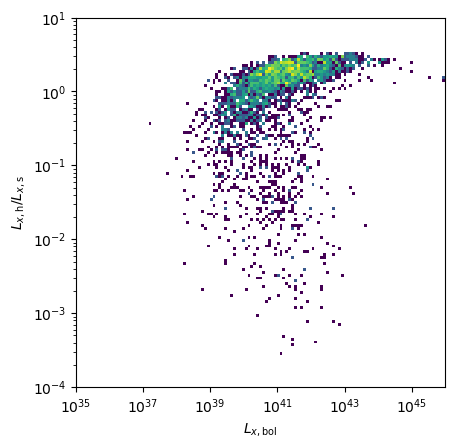

In [7]:
h10, x10, y10 = np.histogram2d(L_bol, L_ratio, bins = [bins_Lx, bins_Lx_ratio])

fig, ax10 = plt.subplots(1,1)

X, Y = np.meshgrid(x10, y10)
ax10.pcolormesh(X, Y, h10.T, norm=norm) 
ax10.axvline(1.0, c='k', ls='--')

ax10.set(xlabel = r"$L_{x,\mathrm{bol}}$",
       ylabel = r"$L_{x,\mathrm{h}}/L_{x,\mathrm{s}}$",
       xlim = [1e35, 1e46],
       ylim = [1e-4, 1e1],
       xscale="log",
       yscale="log",
       box_aspect=1)

plt.show()